In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [34]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [35]:
df = pd.read_csv('../../EDA/data/titanic_toy.csv')

In [36]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [38]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

In [39]:
df.isnull().mean() * 100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [40]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [43]:
X_train['Median_Age'] = X_train['Age'].fillna(median_age)
X_train['Mean_Age'] = X_train['Age'].fillna(mean_age)

X_train['Median_Fare'] = X_train['Fare'].fillna(median_fare)
X_train['Mean_Fare'] = X_train['Fare'].fillna(mean_fare)

In [44]:
X_train.sample(10)

,Age,Fare,Family,Median_Age,Mean_Age,Median_Fare,Mean_Fare
354,NaN,7.2250,0,28.0,29.498846,7.2250,7.2250
566,19.0,7.8958,0,19.0,19.000000,7.8958,7.8958
586,47.0,15.0000,0,47.0,47.000000,15.0000,15.0000
423,28.0,14.4000,2,28.0,28.000000,14.4000,14.4000
444,NaN,8.1125,0,28.0,29.498846,8.1125,8.1125
279,35.0,20.2500,2,35.0,35.000000,20.2500,20.2500
428,NaN,7.7500,0,28.0,29.498846,7.7500,7.7500
526,50.0,10.5000,0,50.0,50.000000,10.5000,10.5000
351,NaN,35.0000,0,28.0,29.498846,35.0000,35.0000
41,27.0,21.0000,1,27.0,27.000000,21.0000,21.0000


In [45]:
print(f'Original Age variation: {X_train["Age"].var()}')
print(f'Imputed Age variation (Median): {X_train["Median_Age"].var()}')
print(f'Imputed Age variation (Mean): {X_train["Mean_Age"].var()}')

print(f"Original Fare variation: {X_train['Fare'].var()}")
print(f"Imputed Fare variation (Median): {X_train['Median_Fare'].var()}")
print(f"Imputed Fare variation (Mean): {X_train['Mean_Fare'].var()}")

Original Age variation: 210.2517072477435
Imputed Age variation (Median): 169.20731007048155
Imputed Age variation (Mean): 168.85193366872227
Original Fare variation: 2761.0314349486343
Imputed Fare variation (Median): 2637.012481677765
Imputed Fare variation (Mean): 2621.232374951235


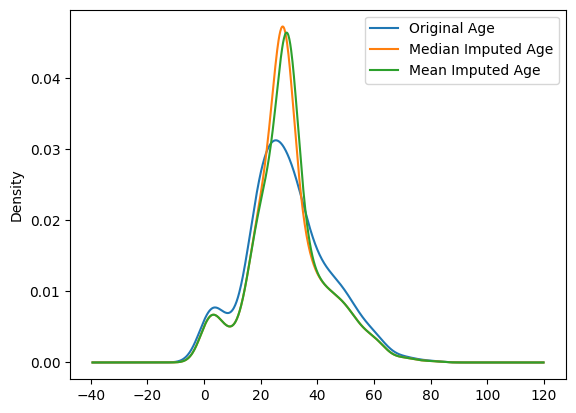

In [48]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Age'].plot(kind='kde', ax=ax, label='Original Age')
X_train['Median_Age'].plot(kind='kde', ax=ax, label='Median Imputed Age')
X_train['Mean_Age'].plot(kind='kde', ax=ax, label='Mean Imputed Age')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

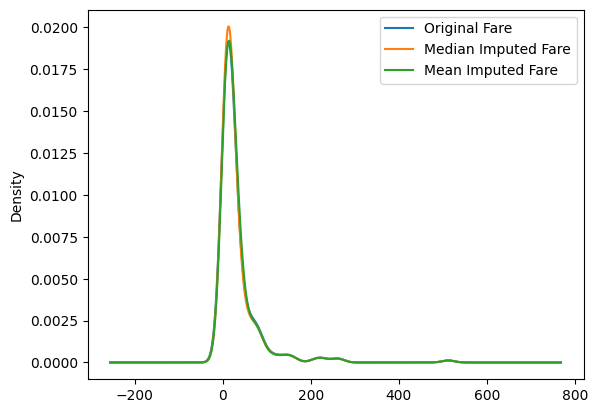

In [49]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train["Fare"].plot(kind='kde', ax=ax, label='Original Fare')
X_train["Median_Fare"].plot(kind='kde', ax=ax, label='Median Imputed Fare')
X_train["Mean_Fare"].plot(kind='kde', ax=ax, label='Mean Imputed Fare')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [50]:
X_train.cov()

,Age,Fare,Family,Median_Age,Mean_Age,Median_Fare,Mean_Fare
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,70.082085,71.193767
Fare,75.481375,2761.031435,18.599163,63.938058,60.224654,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.587710,-5.616299,17.672035,17.657433
Median_Age,210.251707,63.938058,-5.587710,169.207310,168.851934,59.728510,60.700688
Mean_Age,210.251707,60.224654,-5.616299,168.851934,168.851934,56.282518,57.175304
Median_Fare,70.082085,2761.031435,17.672035,59.728510,56.282518,2637.012482,2621.232375
Mean_Fare,71.193767,2761.031435,17.657433,60.700688,57.175304,2621.232375,2621.232375


In [51]:
X_train.corr()

,Age,Fare,Family,Median_Age,Mean_Age,Median_Fare,Mean_Fare
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.087232,0.088944
Fare,0.091482,1.000000,0.207193,0.093496,0.088151,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.255307,-0.256883,0.204536,0.204981
Median_Age,1.000000,0.093496,-0.255307,1.000000,0.998949,0.089416,0.091145
Mean_Age,1.000000,0.088151,-0.256883,0.998949,1.000000,0.084346,0.085941
Median_Fare,0.087232,1.000000,0.204536,0.089416,0.084346,1.000000,0.997003
Mean_Fare,0.088944,1.000000,0.204981,0.091145,0.085941,0.997003,1.000000


<Axes: >

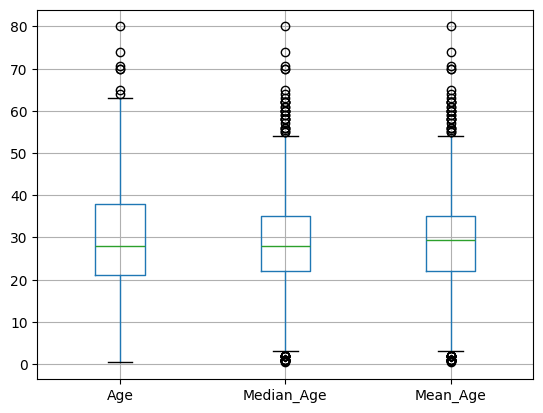

In [55]:
X_train[['Age', 'Median_Age', 'Mean_Age']].boxplot()

<Axes: >

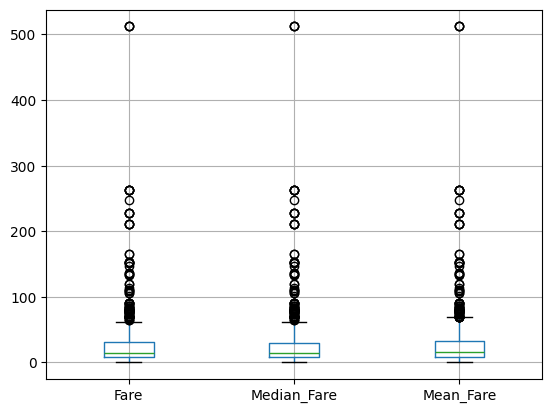

In [56]:
X_train[['Fare', 'Median_Fare', 'Mean_Fare']].boxplot()

In [57]:
##USING SKLEARN'S SIMPLE IMPUTER

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [61]:
trf = ColumnTransformer([
    ('imputer1', imputer1, ['Age']),
    ('imputer2', imputer2, ['Fare'])
], remainder='passthrough')

In [62]:
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [63]:
trf.named_transformers_['imputer1'].statistics_

array([28.])

In [65]:
trf.named_transformers_['imputer2'].statistics_

array([32.51778772])

In [66]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [71]:
X = pd.DataFrame(X_train, columns=X.columns)
X

,Age,Fare,Family
0,45.5,28.500000,0.0
1,23.0,13.000000,0.0
2,32.0,7.925000,0.0
3,26.0,7.854200,1.0
4,6.0,31.275000,6.0
...,...,...,...
707,21.0,7.650000,0.0
708,28.0,31.000000,0.0
709,41.0,32.517788,2.0
710,14.0,120.000000,3.0


In [72]:
X.isnull().sum()

Age       0
Fare      0
Family    0
dtype: int64